In [1]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
import pickle 

# Setup and Preprocessing image

In [2]:
def display_image(image):
  
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 8))
    plt.imshow(image_rgb)
    plt.axis('off')
    plt.show()
   

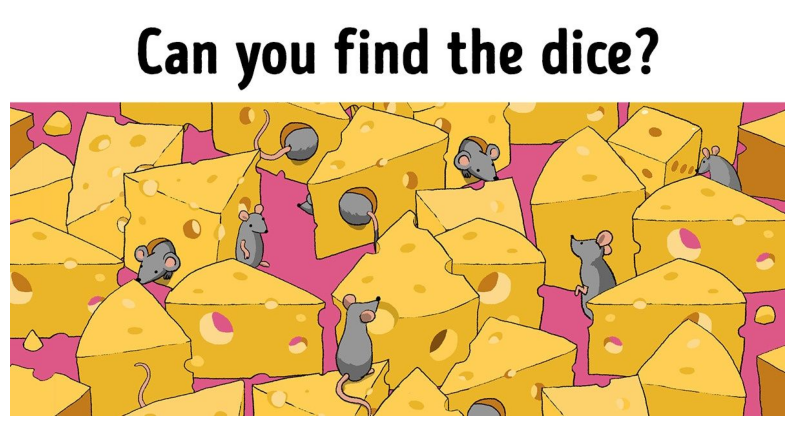

In [ ]:
image_path = "mouse.jpg"
image = cv2.imread(image_path)
display_image(image)


In [4]:
# cắt bỏ vùng trắng và chữ trong ảnh 

def crop_image(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    x, y, w, h = cv2.boundingRect(contours[0])
    cropped_image = image[y:y+h, x:x+w]
    return cropped_image

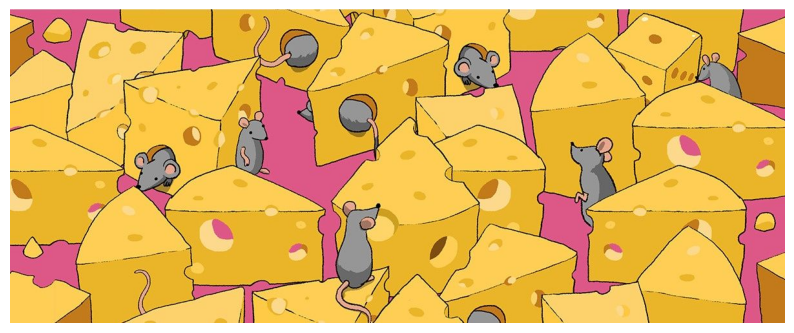

In [5]:
cropped_image = crop_image(image)
display_image(cropped_image)

# Appoarch 1: Nhận dạng chuột bằng cách loại bỏ đi background

**Ý tưởng** : loại bỏ các màu background (hồng) và màu vàng của phomat, khi đó chỉ còn lại màu của chuột

- Các bước :
  
      1. Chuyển đổi sảnh sang dạng hsv và phân tích để lấy mã màu hue (mã màu chính)
      2. Sử dụng biểu đồ histogram để phân tính mã màu nào được lặp lại nhiều nhất -> màu nền hồng và màu phomat
      3. Xây dựng mask chỉ còn lại màu của chuột và lọc bỏ nhiễu khỏi mask
      4. Vẽ bounding box xung quanh các vùng, hợp nhất các vùng box gần nhau theo một threshold 

## Loại bỏ màu nền sử dụng Histogram

In [6]:
hsv_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)

hue_channel = hsv_image[:, :, 0]
hist = cv2.calcHist([hue_channel], [0], None, [180], [0, 179])
indices = np.where(hist > 25000)

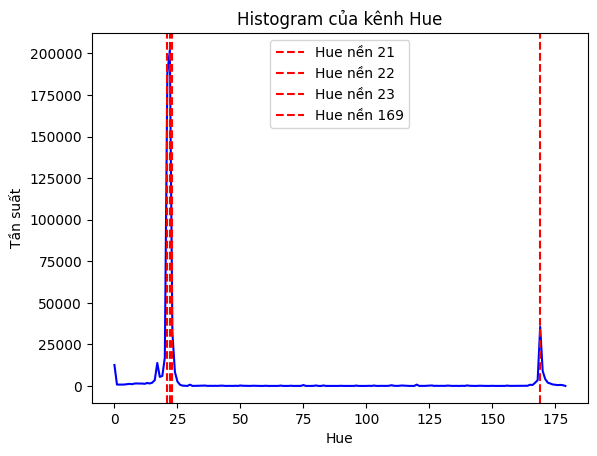

In [7]:
plt.title("Histogram của kênh Hue")
plt.plot(hist, color='blue')
plt.xlabel("Hue")
plt.ylabel("Tần suất")

for idx, i in enumerate(indices[0]): 
    i = int(i)
    plt.axvline(i, color='red', linestyle='--', label=f'Hue nền {i}')

plt.legend()

=> Các màu khoảng 21 -> 23 là màu của phomat, màu khoảng 169 là màu nền

In [8]:
def remove_color(hue, hue_range, image, hsv_image): 
    lower_hue = max(0, hue - hue_range)
    upper_hue = min(179, hue + hue_range)

    lower_bound = np.array([lower_hue, 50, 50], dtype = np.uint8)
    upper_bound = np.array([upper_hue, 255, 255], dtype = np.uint8)
    mask  = cv2.inRange(hsv_image, lower_bound, upper_bound)
    mask_inv = cv2.bitwise_not(mask)

    foreground = cv2.bitwise_and(image, image, mask = mask_inv)
    return foreground 

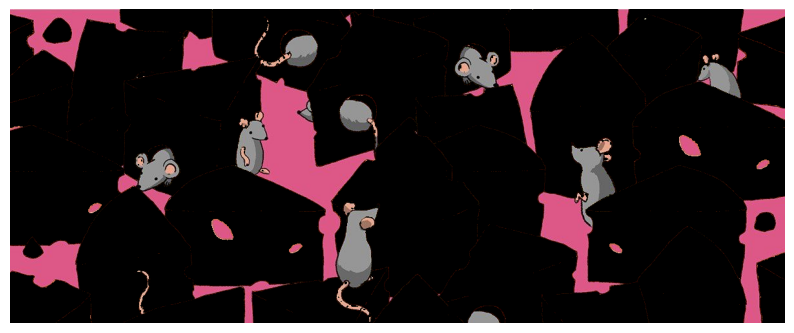

In [9]:
foreground = remove_color(22, 10, cropped_image, hsv_image)
display_image(foreground)

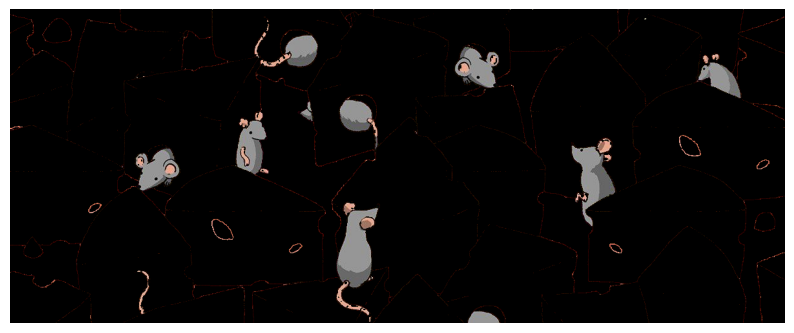

In [10]:
foreground = remove_color(169, 10, foreground, hsv_image)
display_image(foreground)

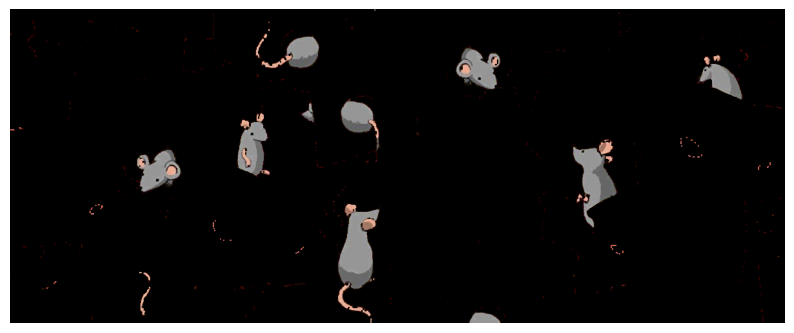

In [11]:
kernel = np.ones((2, 2), np.uint8)
fore_mask = cv2.morphologyEx(foreground, cv2.MORPH_CLOSE, kernel)
fore_mask = cv2.morphologyEx(fore_mask, cv2.MORPH_OPEN, kernel)

display_image(fore_mask)

## Tạo mask và vẽ bounding box cho chuột 

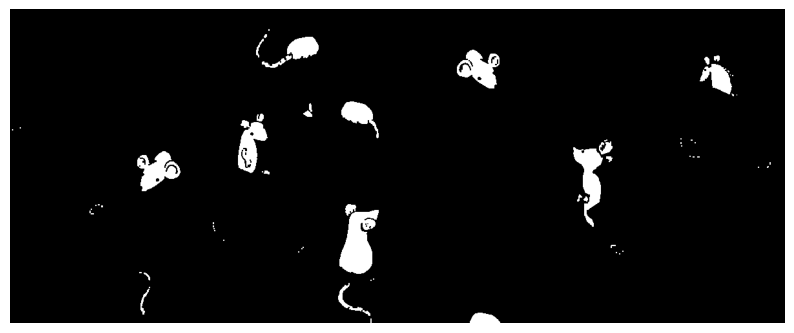

In [12]:
fore_mask = cv2.cvtColor(fore_mask, cv2.COLOR_BGR2GRAY)
_, new_fore_mask = cv2.threshold(fore_mask, 127, 255, cv2.THRESH_BINARY)
display_image(new_fore_mask)

In [13]:
def find_contours(mask, threshold_position, image): 
    """
    Hàm xác định contours và vẽ box cho từng vùng
    """
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    rect_box = []
    for contour in contours:
        x, y, w, h = cv2.boundingRect(contour)
        if w > threshold_position and h > threshold_position:
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            rect_box.append((x, y, w, h))
    return image, rect_box

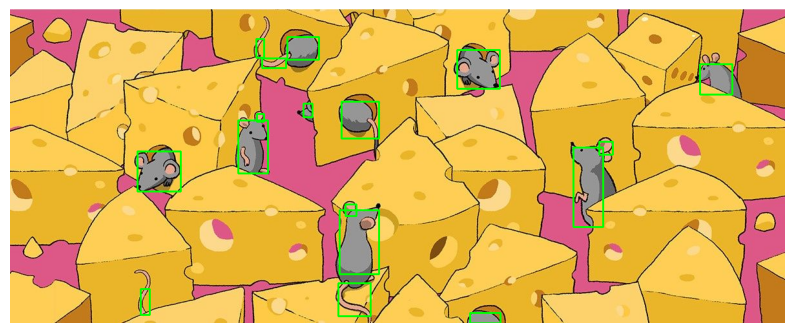

In [14]:
new_image, rect_box = find_contours(new_fore_mask, 10, cropped_image)
display_image(new_image)

In [31]:
"""
Hàm đùng để merge những box gần nhau lại 
"""

def expand_box(box, expand_by=10):
    x, y, w, h = box
    x = max(0, x - expand_by)
    y = max(0, y - expand_by)
    w = w + 2 * expand_by
    h = h + 2 * expand_by
    return (x, y, w, h)

def is_overlapping(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    x1_min, y1_min = x1, y1
    x1_max, y1_max = x1 + w1, y1 + h1
    x2_min, y2_min = x2, y2
    x2_max, y2_max = x2 + w2, y2 + h2
    if x1_max < x2_min or x2_max < x1_min:
        return False
    if y1_max < y2_min or y2_max < y1_min:
        return False
    return True

def merge_boxes(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2
    x_min = min(x1, x2)
    y_min = min(y1, y2)
    x_max = max(x1 + w1, x2 + w2)
    y_max = max(y1 + h1, y2 + h2)
    
    return (x_min, y_min, x_max - x_min, y_max - y_min)

def merge_nearby_boxes(rect_box, expand_by=10):
    expanded_boxes = [expand_box(box, expand_by) for box in rect_box]
 
    merged_boxes = []
    used = [False] * len(rect_box)
    
    for i in range(len(rect_box)):
        if used[i]:
            continue
        
        current_box = rect_box[i]
        used[i] = True
        
        for j in range(len(rect_box)):
            
            if i == j or used[j]:
                continue
            
            if is_overlapping(expanded_boxes[i], expanded_boxes[j]):
                current_box = merge_boxes(current_box, rect_box[j])
                used[j] = True
        
        merged_boxes.append(current_box)
    
    return merged_boxes

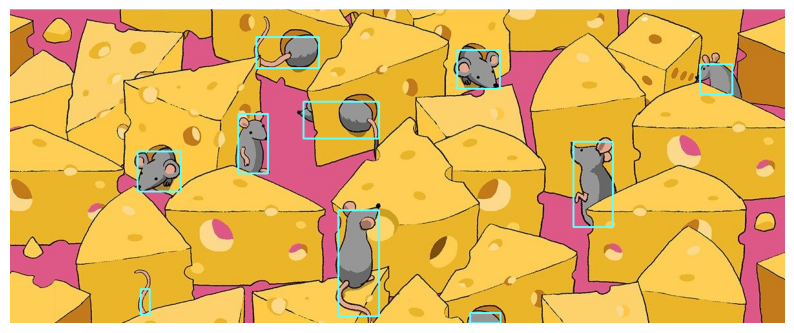

In [36]:
merged_boxes = merge_nearby_boxes(rect_box, expand_by=25)

new_image = cv2.imread(image_path)
new_cropped_image = crop_image(new_image)

for box in merged_boxes:
    x, y, w, h = box
    if w * h > 500: 
        cv2.rectangle(new_cropped_image, (x, y), (x + w, y + h), (255, 255 , 100), 2)

display_image(new_cropped_image)

# Appoarch 2: Nhận dạng chuột thông qua xác định màu thân và màu đuôi

**Ý tưởng** : Xác định vùng màu của thân và đuôi chuôt => tạo mask cho mỗi vùng. Sử dụng phép union cho 2 mask này để tọa 1 mask chung. Sử dụng mask này để nhận dạng bounding box cho chuột

## Xác định khoảng màu của thân và đuôi chuột 

**Cách 1**:  Lấy sample trực tiếp các màu thuộc vùng đuôi của chuột

In [ ]:
sample_pixel = []

def click_event(event, x, y,  flags, param):
    if event == cv2.EVENT_LBUTTONDOWN:
        pixel = cropped_image[y, x]
        pixel_hsv = cv2.cvtColor(np.uint8([[pixel]]), cv2.COLOR_BGR2HSV)[0][0]
        print(f"Clicked pixel: BGR: {pixel}, HSV: {pixel_hsv}")
        sample_pixel.append(pixel_hsv)


cv2.imshow("Image", cropped_image)
cv2.setMouseCallback("Image", click_event)
cv2.waitKey(0)
cv2.destroyAllWindows()

qt.qpa.plugin: Could not find the Qt platform plugin "wayland" in "/home/trung/.miniconda3/envs/workspace/lib/python3.10/site-packages/cv2/qt/plugins"


Clicked pixel: BGR: [147 147 147], HSV: [  0   0 147]
Clicked pixel: BGR: [111 111 111], HSV: [  0   0 111]
Clicked pixel: BGR: [106 106 106], HSV: [  0   0 106]
Clicked pixel: BGR: [110 110 110], HSV: [  0   0 110]
Clicked pixel: BGR: [98 98 98], HSV: [ 0  0 98]
Clicked pixel: BGR: [108 113 114], HSV: [ 25  13 114]
Clicked pixel: BGR: [111 116 117], HSV: [ 25  13 117]
Clicked pixel: BGR: [105  93  93], HSV: [120  29 105]
Clicked pixel: BGR: [103 100  96], HSV: [103  17 103]
Clicked pixel: BGR: [90 99 96], HSV: [40 23 99]
Clicked pixel: BGR: [103  94  91], HSV: [113  30 103]
Clicked pixel: BGR: [ 33 114 151], HSV: [ 21 199 151]
Clicked pixel: BGR: [  0 255   0], HSV: [ 60 255 255]
Clicked pixel: BGR: [ 36 181 236], HSV: [ 22 216 236]
Clicked pixel: BGR: [ 46 182 230], HSV: [ 22 204 230]
Clicked pixel: BGR: [  0 255   0], HSV: [ 60 255 255]
Clicked pixel: BGR: [ 29 117 158], HSV: [ 20 208 158]
Clicked pixel: BGR: [ 55  98 117], HSV: [ 21 135 117]
Clicked pixel: BGR: [111 100 103], HSV: 

In [13]:
# with open ('sample_pixel.pkl', 'wb') as f:
#     pickle.dump(sample_pixel, f)

- Load các sample đã được chọn và tính khoảng min và max cho từng h, s, v 

In [14]:
with open('sample_pixel_data.pkl', 'rb') as f:
    sample_pixel = pickle.load(f)

print("Sample pixel data loaded from file with length:", len(sample_pixel))
sample_pixel = np.array(sample_pixel)

Sample pixel data loaded from file with length: 275


In [15]:
min_h = np.min(sample_pixel, axis=0)[0]
max_h = np.max(sample_pixel, axis=0)[0]

max_s = np.max(sample_pixel, axis=0)[1]
min_s = np.min(sample_pixel, axis=0)[1]

max_v = np.max(sample_pixel, axis=0)[2]
min_v = np.min(sample_pixel, axis=0)[2]


print(f"HSV values range : S: {min_s} - {max_s}")
print(f"HSV values range : V: {min_v} - {max_v}") 
print(f"HSV values range : H: {min_h} - {max_h}")

HSV values range : S: 46 - 255
HSV values range : V: 53 - 255
HSV values range : H: 0 - 18


**Cách 2** sử dụng miền ROI để chọn màu

In [16]:
# # lựa chọn vùng ROI để trích xuất thông tin hình ảnh 
# hsv_image = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)
# roi = cv2.selectROI("Select ROI", image, showCrosshair=True, fromCenter=False)
# x, y, w, h = roi
# cv2.destroyAllWindows()

In [17]:
# roi 

In [18]:
# roi_hsv = hsv_image[y:y+h, x:x+w]
# h_min, s_min, v_min = np.min(roi_hsv, axis=(0, 1))
# h_max, s_max, v_max = np.max(roi_hsv, axis=(0, 1))

In [19]:
# print(f"ROI HSV Range: H: {h_min}-{h_max}, S: {s_min}-{s_max}, V: {v_min}-{v_max}")

## 2. Sử dụng mask trên cả vùng lông và đuôi tìm được

In [ ]:
new_image = cv2.imread('mouse.jpg')
cropped_image = crop_image(new_image)

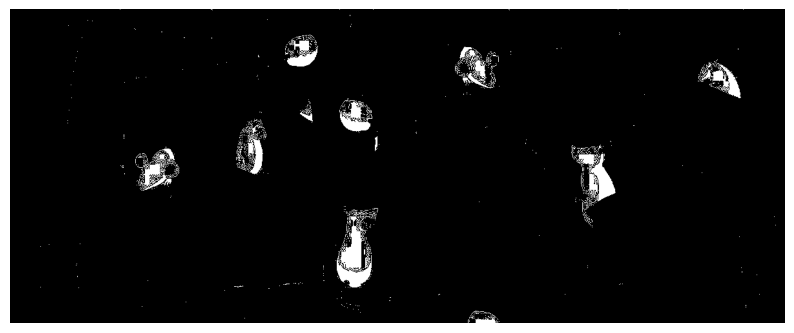

In [46]:
hsv = cv2.cvtColor(cropped_image, cv2.COLOR_BGR2HSV)

lower_gray = np.array([0, 0, 40], dtype=np.uint8)
upper_gray = np.array([180, 120, 150], dtype=np.uint8)
fur_mask = cv2.inRange(hsv, lower_gray, upper_gray)

display_image(fur_mask)

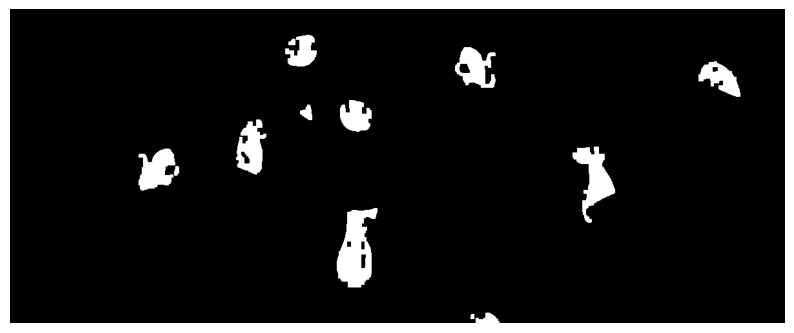

In [47]:
kernel = np.ones((5, 5), np.uint8)
fur_mask = cv2.morphologyEx(fur_mask, cv2.MORPH_CLOSE, kernel)
fur_mask = cv2.morphologyEx(fur_mask, cv2.MORPH_OPEN, kernel)

display_image(fur_mask)

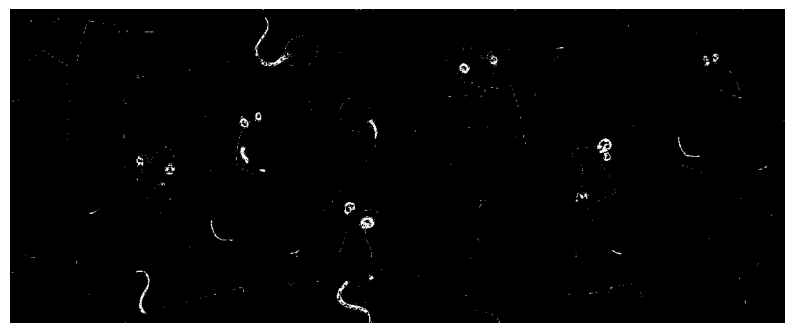

In [48]:
lower_pink = np.array([7, 46, 53], dtype=np.uint8)
upper_pink = np.array([18, 100, 255], dtype=np.uint8)
tail_mask = cv2.inRange(hsv, lower_pink, upper_pink)

display_image(tail_mask)

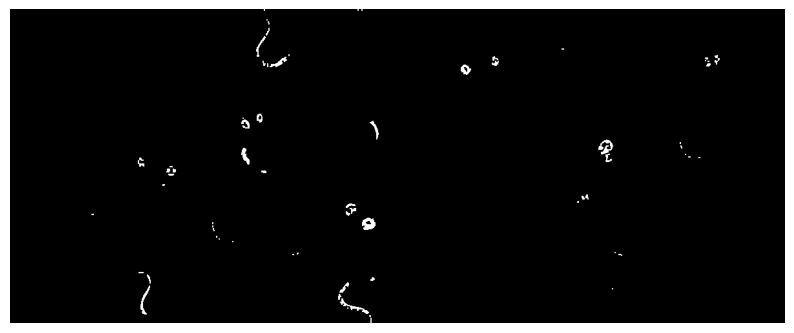

In [49]:
kernel = np.ones((2, 2), np.uint8)
tail_mask = cv2.morphologyEx(tail_mask, cv2.MORPH_CLOSE, kernel)
tail_mask = cv2.morphologyEx(tail_mask, cv2.MORPH_OPEN, kernel)

display_image(tail_mask)

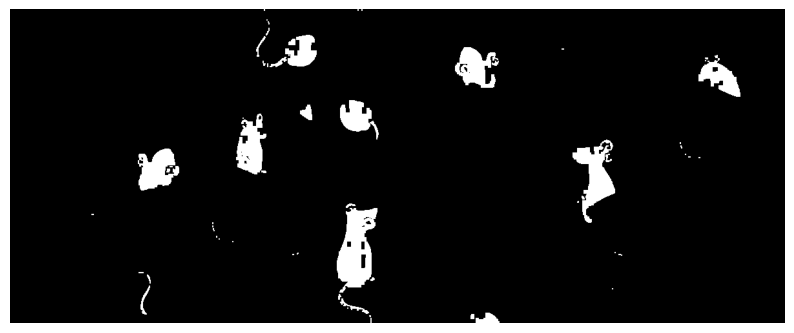

In [50]:
# phép hợp giữa 2 ảnh binary 
union_mask = cv2.bitwise_or(fur_mask, tail_mask)
display_image(union_mask) 

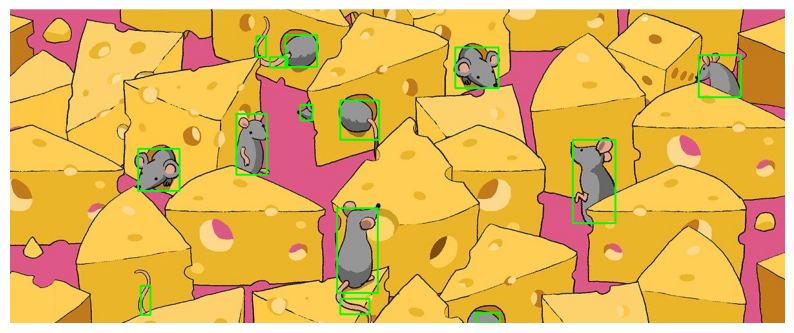

In [51]:
contours, _ = cv2.findContours(union_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for contour in contours:
    x, y, w, h = cv2.boundingRect(contour)
    if w > 10 and h > 10:
        x, y, w, h = cv2.boundingRect(contour)
        cropped_image =  cv2.rectangle(cropped_image, (x, y), (x + w, y + h), (0, 255, 0), 2)

display_image(cropped_image)

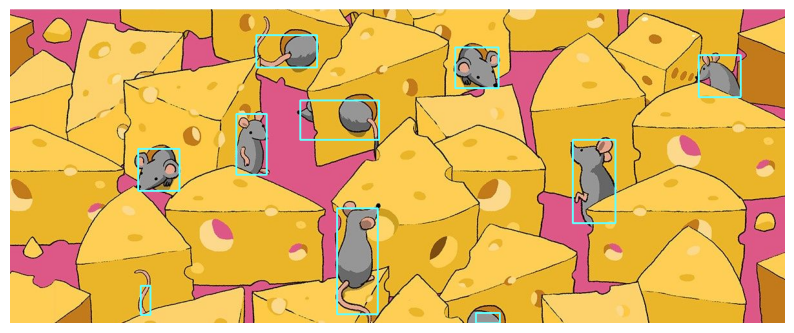

In [52]:
rect_box = []
contours, _ = cv2.findContours(union_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    if w > 10 and h > 10: 
        rect_box.append((x, y, w, h))
        

merged_boxes = merge_nearby_boxes(rect_box, expand_by=25)

new_image = cv2.imread(image_path)
new_cropped_image = crop_image(new_image)

for box in merged_boxes:
    x, y, w, h = box
    cv2.rectangle(new_cropped_image, (x, y), (x + w, y + h), (255, 255 , 100), 2)

display_image(new_cropped_image)


In [53]:
print("Number of mouses:", len(merged_boxes))

Number of mouses: 10
